# 📊 Data Description — Semua Data GPS

Notebook ini menampilkan **deskripsi lengkap** dari keseluruhan dataset GPS
periode Oktober 2021 - Juni 2022 untuk wilayah Daerah Istimewa Yogyakarta (DIY).

> **⚡ Pendekatan: DuckDB dengan Disk Spilling**
>
> Semua operasi berat (agregasi, statistik, distinct count, dll) dijalankan
> melalui DuckDB yang mendukung disk spilling — sehingga aman untuk dataset
> berukuran besar (ratusan juta baris) tanpa crash karena kehabisan RAM.
> Hanya hasil agregat kecil yang ditarik ke pandas untuk plotting.

**Isi notebook:**
1. Koneksi DuckDB & Preview Data
2. Dimensi Dataset (Jumlah Row & Column)
3. Schema & Tipe Data
4. Memory / File Size Info
5. Statistik Deskriptif (min, max, mean, std, percentiles)
6. Nilai Distinct (Unique) per Kolom
7. Distinct Rows & Duplikasi
8. Analisis Missing Values / Null
9. Distribusi Data — Histogram tiap Kolom Numerik
10. Distribusi Data — Boxplot (percentile-based)
11. Korelasi antar Kolom Numerik
12. Analisis Temporal (Timestamp -> Datetime)
13. Distribusi Spasial (Scatter Plot Lat/Lon)
14. Analisis Perangkat (MAID)
15. Ringkasan Akhir

---
## 0 · Setup & Koneksi DuckDB

In [1]:
import os
from pathlib import Path

import duckdb
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# Import shared config (saat import, shared.py set matplotlib backend ke "Agg")
from shared import get_con, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX

# Override Agg backend SETELAH import shared agar plot tampil inline di Jupyter
%matplotlib inline

# -- Konfigurasi --------------------------------------------------------------
PARQUET_PATH = "./DataGPS_parquet/all_gps_data_no_dup.parquet"
PLOTS_DIR = "./plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Matplotlib style
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "sans-serif",
})
sns.set_palette("viridis")

# -- DuckDB Connection (disk spilling aktif) ---------------------------------
con = get_con(os.getcwd())

# Verifikasi konfigurasi
print("⚙️  DuckDB Configuration:")
for setting in ["memory_limit", "threads", "temp_directory"]:
    val = con.execute(f"SELECT current_setting('{setting}')").fetchone()[0]
    print(f"   {setting}: {val}")

# Buat VIEW agar query ringkas
con.execute(f"CREATE OR REPLACE VIEW gps AS SELECT * FROM read_parquet('{PARQUET_PATH}')")

print(f"\n✅ View 'gps' dibuat dari: {PARQUET_PATH}")

⚙️  DuckDB Configuration:
   memory_limit: 3.7 GiB
   threads: 4
   temp_directory: /home/repal/Github/skripsi/./.duckdb_tmp

✅ View 'gps' dibuat dari: ./DataGPS_parquet/all_gps_data_no_dup.parquet


---
## 1 · Preview Data

In [2]:
print("=" * 90)
print("HEAD — 5 baris pertama")
print("=" * 90)
con.execute("SELECT * FROM gps LIMIT 5").df()

HEAD — 5 baris pertama


,maid,latitude,longitude,timestamp
0,0054d7a0-523c-402f-9ea7-e9b1d4db5736,-7.764816,110.424927,1636689274
1,0054d7a0-523c-402f-9ea7-e9b1d4db5736,-7.764816,110.424927,1636689324
2,0054d7a0-523c-402f-9ea7-e9b1d4db5736,-7.764830,110.424942,1636689731
3,0054d7a0-523c-402f-9ea7-e9b1d4db5736,-7.764840,110.424927,1636689731
4,0054d7a0-523c-402f-9ea7-e9b1d4db5736,-7.764840,110.424919,1636689731


In [3]:
print("=" * 90)
print("TAIL — 5 baris terakhir (berdasarkan rowid)")
print("=" * 90)
con.execute("""
    SELECT * FROM gps
    OFFSET (SELECT COUNT(*) - 5 FROM gps)
    LIMIT 5
""").df()

TAIL — 5 baris terakhir (berdasarkan rowid)


,maid,latitude,longitude,timestamp
0,ffa01ef3-1d36-499b-8bb1-5609e57b8469,-7.730650,110.437260,1638299527
1,ffa01ef3-1d36-499b-8bb1-5609e57b8469,-7.730643,110.437263,1638299527
2,ffa01ef3-1d36-499b-8bb1-5609e57b8469,-7.730650,110.437263,1638299527
3,ffa01ef3-1d36-499b-8bb1-5609e57b8469,-7.730660,110.437248,1638299570
4,ffa01ef3-1d36-499b-8bb1-5609e57b8469,-7.730660,110.437250,1638299570


In [4]:
print("=" * 90)
print("SAMPLE — 10 baris acak (TABLESAMPLE)")
print("=" * 90)
con.execute("SELECT * FROM gps USING SAMPLE 10 ROWS").df()

SAMPLE — 10 baris acak (TABLESAMPLE)


,maid,latitude,longitude,timestamp
0,00007d1d-2f96-4ed8-b169-441e79494e22,-7.907592,110.311325,1643560690
1,00030675-2a56-4380-a376-99eb003beb5c,-7.742629,110.412117,1640508816
2,00071ae2-d9dc-4e14-b3fc-9f8a818ee767,-7.690500,110.391296,1640852839
3,00071ae2-d9dc-4e14-b3fc-9f8a818ee767,-7.814110,110.363403,1644820870
4,00071ae2-d9dc-4e14-b3fc-9f8a818ee767,-7.758871,110.419868,1648167860
5,00071ae2-d9dc-4e14-b3fc-9f8a818ee767,-7.759940,110.406387,1653928236
6,002f69e0-84b3-433b-9ba4-e30bbd96e3d9,-7.800000,110.300003,1640504348
7,002f9404-aff5-473a-141d-8e460ad55777,-7.780212,110.388123,1654331682
8,003127fa-39d5-4a38-88be-00811acc72a5,-7.876490,110.346443,1636162073
9,003127fa-39d5-4a38-88be-00811acc72a5,-7.876431,110.346390,1637765159


---
## 2 · Dimensi Dataset

In [5]:
dims = con.execute("""
    SELECT 
        COUNT(*)      AS total_rows,
        4             AS total_columns,
        COUNT(*) * 4  AS total_cells
    FROM gps
""").df()

n_rows = int(dims["total_rows"].iloc[0])
n_cols = int(dims["total_columns"].iloc[0])

print("┌──────────────────────────────────────┐")
print("│        DIMENSI DATASET               │")
print("├──────────────────────────────────────┤")
print(f"│  Jumlah Baris (Rows)    : {n_rows:>10,} │")
print(f"│  Jumlah Kolom (Columns) : {n_cols:>10,} │")
print(f"│  Total Sel Data         : {n_rows * n_cols:>10,} │")
print("└──────────────────────────────────────┘")

# Nama kolom
col_names = con.execute("SELECT column_name FROM information_schema.columns WHERE table_name='gps'").df()
print(f"\nNama Kolom: {col_names['column_name'].tolist()}")

┌──────────────────────────────────────┐
│        DIMENSI DATASET               │
├──────────────────────────────────────┤
│  Jumlah Baris (Rows)    : 169,509,324 │
│  Jumlah Kolom (Columns) :          4 │
│  Total Sel Data         : 678,037,296 │
└──────────────────────────────────────┘

Nama Kolom: ['maid', 'latitude', 'longitude', 'timestamp']


---
## 3 · Schema & Tipe Data

In [6]:
print("=" * 60)
print("SCHEMA — TIPE DATA TIAP KOLOM")
print("=" * 60)
schema_df = con.execute("""
    SELECT 
        column_name  AS "Kolom",
        data_type    AS "Tipe DuckDB",
        is_nullable  AS "Nullable"
    FROM information_schema.columns
    WHERE table_name = 'gps'
    ORDER BY ordinal_position
""").df()
schema_df

SCHEMA — TIPE DATA TIAP KOLOM


,Kolom,Tipe DuckDB,Nullable
0,maid,VARCHAR,YES
1,latitude,DOUBLE,YES
2,longitude,DOUBLE,YES
3,timestamp,BIGINT,YES


---
## 4 · Informasi File & Ukuran

In [7]:
file_path = Path(PARQUET_PATH)
file_stat = file_path.stat()
file_size_mb = file_stat.st_size / 1024 / 1024

# Estimasi ukuran uncompressed (dari DuckDB)
est_size = con.execute("""
    SELECT 
        COUNT(*) AS rows,
        -- Estimasi: maid (~36 bytes UUID) + lat (8) + lon (8) + timestamp (8)
        COUNT(*) * (36 + 8 + 8 + 8) / 1024.0 / 1024.0 AS estimated_uncompressed_mb
    FROM gps
""").df()

print("=" * 60)
print("INFORMASI FILE")
print("=" * 60)
print(f"  📁 Path               : {file_path.resolve()}")
print(f"  📏 Ukuran File (disk) : {file_size_mb:.2f} MB ({file_stat.st_size:,} bytes)")
print(f"  📏 Estimasi Raw       : {est_size['estimated_uncompressed_mb'].iloc[0]:.2f} MB")
print(f"  📏 Rasio Kompresi     : {est_size['estimated_uncompressed_mb'].iloc[0] / file_size_mb:.2f}x")

INFORMASI FILE
  📁 Path               : /home/repal/Github/skripsi/DataGPS_parquet/all_gps_data_no_dup.parquet
  📏 Ukuran File (disk) : 1013.41 MB (1,062,640,619 bytes)
  📏 Estimasi Raw       : 9699.40 MB
  📏 Rasio Kompresi     : 9.57x


---
## 5 · Statistik Deskriptif

Semua statistik dihitung langsung di DuckDB — tidak ada data yang di-load ke RAM.

In [8]:
print("=" * 80)
print("STATISTIK DESKRIPTIF — Kolom Numerik (Approximate)")
print("=" * 80)

desc_df = con.execute("""
    SELECT
        'latitude' AS kolom,
        MIN(latitude)                          AS min,
        APPROX_QUANTILE(latitude, 0.25)        AS q1,
        APPROX_QUANTILE(latitude, 0.5)         AS median,
        AVG(latitude)                          AS mean,
        APPROX_QUANTILE(latitude, 0.75)        AS q3,
        MAX(latitude)                          AS max,
        STDDEV_SAMP(latitude)                  AS std,
        VARIANCE(latitude)                     AS variance,
        SKEWNESS(latitude)                     AS skewness,
        KURTOSIS(latitude)                     AS kurtosis,
        MAX(latitude) - MIN(latitude)          AS range,
        APPROX_QUANTILE(latitude, 0.75) - APPROX_QUANTILE(latitude, 0.25) AS iqr
    FROM gps
    
    UNION ALL
    
    SELECT
        'longitude',
        MIN(longitude),
        APPROX_QUANTILE(longitude, 0.25),
        APPROX_QUANTILE(longitude, 0.5),
        AVG(longitude),
        APPROX_QUANTILE(longitude, 0.75),
        MAX(longitude),
        STDDEV_SAMP(longitude),
        VARIANCE(longitude),
        SKEWNESS(longitude),
        KURTOSIS(longitude),
        MAX(longitude) - MIN(longitude),
        APPROX_QUANTILE(longitude, 0.75) - APPROX_QUANTILE(longitude, 0.25)
    FROM gps
    
    UNION ALL
    
    SELECT
        'timestamp',
        MIN(timestamp)::DOUBLE,
        APPROX_QUANTILE(timestamp, 0.25)::DOUBLE,
        APPROX_QUANTILE(timestamp, 0.5)::DOUBLE,
        AVG(timestamp)::DOUBLE,
        APPROX_QUANTILE(timestamp, 0.75)::DOUBLE,
        MAX(timestamp)::DOUBLE,
        STDDEV_SAMP(timestamp),
        VARIANCE(timestamp),
        SKEWNESS(timestamp),
        KURTOSIS(timestamp),
        (MAX(timestamp) - MIN(timestamp))::DOUBLE,
        APPROX_QUANTILE(timestamp, 0.75) - APPROX_QUANTILE(timestamp, 0.25)::DOUBLE
    FROM gps
""").df()

desc_df.set_index("kolom", inplace=True)
desc_df

STATISTIK DESKRIPTIF — Kolom Numerik (Approximate)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min,q1,median,mean,q3,max,std,variance,skewness,kurtosis,range,iqr
kolom,,,,,,,,,,,,
latitude,-8.201930e+00,-7.831046e+00,-7.793395e+00,-7.798922e+00,-7.753283e+00,-7.556430e+00,7.953836e-02,6.326350e-03,-0.722060,1.293364,6.455000e-01,7.776339e-02
longitude,1.100032e+02,1.103367e+02,1.103704e+02,1.103716e+02,1.104083e+02,1.108323e+02,9.229452e-02,8.518278e-03,0.660118,-378.077965,8.291016e-01,7.155104e-02
timestamp,1.634947e+09,1.637939e+09,1.641384e+09,1.643152e+09,1.646809e+09,1.654630e+09,6.107911e+06,3.730658e+13,0.635537,-0.855169,1.968286e+07,8.870109e+06


---
## 6 · Nilai Distinct (Unique) per Kolom

In [9]:
print("=" * 60)
print("DISTINCT / UNIQUE VALUES PER KOLOM")
print("=" * 60)

distinct_df = con.execute(f"""
    WITH distinct_counts AS (
        SELECT 
            COUNT(DISTINCT maid)      AS maid_cnt,
            COUNT(DISTINCT latitude)  AS lat_cnt,
            COUNT(DISTINCT longitude) AS lon_cnt,
            COUNT(DISTINCT timestamp) AS ts_cnt
        FROM gps
    )
    SELECT
        'maid' AS kolom, maid_cnt AS distinct_count, {n_rows} AS total_rows,
        ROUND(maid_cnt * 100.0 / {n_rows}, 4) AS "rasio_distinct_%"
    FROM distinct_counts
    UNION ALL
    SELECT
        'latitude', lat_cnt, {n_rows},
        ROUND(lat_cnt * 100.0 / {n_rows}, 4)
    FROM distinct_counts
    UNION ALL
    SELECT
        'longitude', lon_cnt, {n_rows},
        ROUND(lon_cnt * 100.0 / {n_rows}, 4)
    FROM distinct_counts
    UNION ALL
    SELECT
        'timestamp', ts_cnt, {n_rows},
        ROUND(ts_cnt * 100.0 / {n_rows}, 4)
    FROM distinct_counts
""").df()

distinct_df

DISTINCT / UNIQUE VALUES PER KOLOM


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,kolom,distinct_count,total_rows,rasio_distinct_%
0,maid,4281537,169509324,2.5258
1,latitude,878832,169509324,0.5185
2,longitude,195922,169509324,0.1156
3,timestamp,16268263,169509324,9.5973


---
## 7 · Distinct Rows & Duplikasi

In [10]:
print("=" * 60)
print("DISTINCT ROWS & DUPLIKASI (EXACT)")
print("=" * 60)

dup_df = con.execute("""
    WITH stats AS (
        SELECT
            (SELECT COUNT(*) FROM gps) AS total_rows,
            (SELECT COUNT(*) FROM (SELECT DISTINCT * FROM gps)) AS distinct_rows
    )
    SELECT
        total_rows,
        distinct_rows,
        total_rows - distinct_rows AS duplicate_rows,
        ROUND((total_rows - distinct_rows) * 100.0 / total_rows, 4) AS "rasio_duplikasi_%"
    FROM stats
""").df()

n_distinct_rows = int(dup_df["distinct_rows"].iloc[0])
n_duplicate_rows = int(dup_df["duplicate_rows"].iloc[0])

print(f"  Total Rows         : {n_rows:>12,}")
print(f"  Distinct Rows      : {n_distinct_rows:>12,}")
print(f"  Duplicate Rows     : {n_duplicate_rows:>12,}")
print(f"  Rasio Duplikasi    : {dup_df['rasio_duplikasi_%'].iloc[0]:.4f}%")

DISTINCT ROWS & DUPLIKASI (EXACT)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Total Rows         :  169,509,324
  Distinct Rows      :  169,509,324
  Duplicate Rows     :            0
  Rasio Duplikasi    : 0.0000%


---
## 8 · Analisis Missing Values / Null

In [11]:
print("=" * 60)
print("MISSING VALUES / NULL ANALYSIS")
print("=" * 60)

null_df = con.execute(f"""
    SELECT
        'maid'      AS kolom,
        SUM(CASE WHEN maid      IS NULL THEN 1 ELSE 0 END) AS null_count,
        SUM(CASE WHEN maid      IS NOT NULL THEN 1 ELSE 0 END) AS non_null_count,
        ROUND(SUM(CASE WHEN maid IS NULL THEN 1 ELSE 0 END) * 100.0 / {n_rows}, 4) AS "null_%"
    FROM gps
    UNION ALL
    SELECT 'latitude',
        SUM(CASE WHEN latitude  IS NULL THEN 1 ELSE 0 END),
        SUM(CASE WHEN latitude  IS NOT NULL THEN 1 ELSE 0 END),
        ROUND(SUM(CASE WHEN latitude IS NULL THEN 1 ELSE 0 END) * 100.0 / {n_rows}, 4)
    FROM gps
    UNION ALL
    SELECT 'longitude',
        SUM(CASE WHEN longitude IS NULL THEN 1 ELSE 0 END),
        SUM(CASE WHEN longitude IS NOT NULL THEN 1 ELSE 0 END),
        ROUND(SUM(CASE WHEN longitude IS NULL THEN 1 ELSE 0 END) * 100.0 / {n_rows}, 4)
    FROM gps
    UNION ALL
    SELECT 'timestamp',
        SUM(CASE WHEN timestamp IS NULL THEN 1 ELSE 0 END),
        SUM(CASE WHEN timestamp IS NOT NULL THEN 1 ELSE 0 END),
        ROUND(SUM(CASE WHEN timestamp IS NULL THEN 1 ELSE 0 END) * 100.0 / {n_rows}, 4)
    FROM gps
""").df()

total_nulls = int(null_df["null_count"].sum())
total_cells = n_rows * n_cols

print(f"\n  Total sel null     : {total_nulls:>12,} dari {total_cells:,}")
print(f"  Persentase null    : {total_nulls / total_cells * 100:.4f}%")
print()
null_df

MISSING VALUES / NULL ANALYSIS


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


  Total sel null     :            0 dari 678,037,296
  Persentase null    : 0.0000%



,kolom,null_count,non_null_count,null_%
0,maid,0.0,169509324.0,0.0
1,latitude,0.0,169509324.0,0.0
2,longitude,0.0,169509324.0,0.0
3,timestamp,0.0,169509324.0,0.0


---
## 9 · Min & Max per Kolom

In [12]:
print("=" * 70)
print("MINIMUM & MAXIMUM PER KOLOM")
print("=" * 70)

minmax_df = con.execute("""
    SELECT
        'maid' AS kolom,
        MIN(maid)::VARCHAR AS min_val,
        MAX(maid)::VARCHAR AS max_val,
        '—' AS min_datetime,
        '—' AS max_datetime,
        '—' AS range_val
    FROM gps
    UNION ALL
    SELECT
        'latitude',
        ROUND(MIN(latitude), 6)::VARCHAR,
        ROUND(MAX(latitude), 6)::VARCHAR,
        '—', '—',
        ROUND(MAX(latitude) - MIN(latitude), 6)::VARCHAR
    FROM gps
    UNION ALL
    SELECT
        'longitude',
        ROUND(MIN(longitude), 6)::VARCHAR,
        ROUND(MAX(longitude), 6)::VARCHAR,
        '—', '—',
        ROUND(MAX(longitude) - MIN(longitude), 6)::VARCHAR
    FROM gps
    UNION ALL
    SELECT
        'timestamp',
        MIN(timestamp)::VARCHAR,
        MAX(timestamp)::VARCHAR,
        STRFTIME(TO_TIMESTAMP(MIN(timestamp)), '%Y-%m-%d %H:%M:%S'),
        STRFTIME(TO_TIMESTAMP(MAX(timestamp)), '%Y-%m-%d %H:%M:%S'),
        (MAX(timestamp) - MIN(timestamp))::VARCHAR
    FROM gps
""").df()

minmax_df

MINIMUM & MAXIMUM PER KOLOM


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,kolom,min_val,max_val,min_datetime,max_datetime,range_val
0,maid,00000000-0000-0000-0000-000000000000,fffffd77-ce7d-43fe-9ac0-73e5cb40f162,—,—,—
1,latitude,-8.20193,-7.55643,—,—,0.6455
2,longitude,110.003189,110.832291,—,—,0.829102
3,timestamp,1634947200,1654630065,2021-10-23 07:00:00,2022-06-08 02:27:45,19682865


---
## 10 · Distribusi Data — Histogram tiap Kolom Numerik

Histogram dihitung via DuckDB `histogram()` — hanya bin counts yang ditarik ke Python.

In [13]:
# Histogram via binning di DuckDB (latitude)
def duckdb_histogram(con, col: str, n_bins: int = 80):
    """Hitung histogram di DuckDB, return bin_edges & counts."""
    
    # 1. Hitung min dan max terpisah (mencegah memory explosion dari cross join)
    minmax_df = con.execute(f"SELECT MIN({col}) AS vmin, MAX({col}) AS vmax FROM gps").df()
    vmin = float(minmax_df["vmin"].iloc[0])
    vmax = float(minmax_df["vmax"].iloc[0])
    
    # Cegah division by zero apabila datanya konstan
    if vmax == vmin:
        bin_width = 1.0
    else:
        bin_width = (vmax - vmin) / n_bins
        
    # 2. Lakukan grouping langsung menggunakan konstanta angka bukan lewat CTE
    result = con.execute(f"""
        SELECT 
            FLOOR(({col} - {vmin}) / {bin_width}) AS bin_idx,
            COUNT(*) AS cnt
        FROM gps
        WHERE {col} IS NOT NULL
        GROUP BY 1
        ORDER BY bin_idx
    """).df()
    
    result["bin_center"] = vmin + (result["bin_idx"] + 0.5) * bin_width
    result["bin_left"] = vmin + result["bin_idx"] * bin_width
    
    return result, bin_width

# Statistik mean/median (Gunakan APPROX_QUANTILE alih-alih MEDIAN persis karena memakan banyak RAM)
stats_for_hist = con.execute("""
    SELECT
        AVG(latitude) AS lat_mean, APPROX_QUANTILE(latitude, 0.5) AS lat_median,
        AVG(longitude) AS lon_mean, APPROX_QUANTILE(longitude, 0.5) AS lon_median,
        AVG(timestamp) AS ts_mean, APPROX_QUANTILE(timestamp, 0.5)::DOUBLE AS ts_median
    FROM gps
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

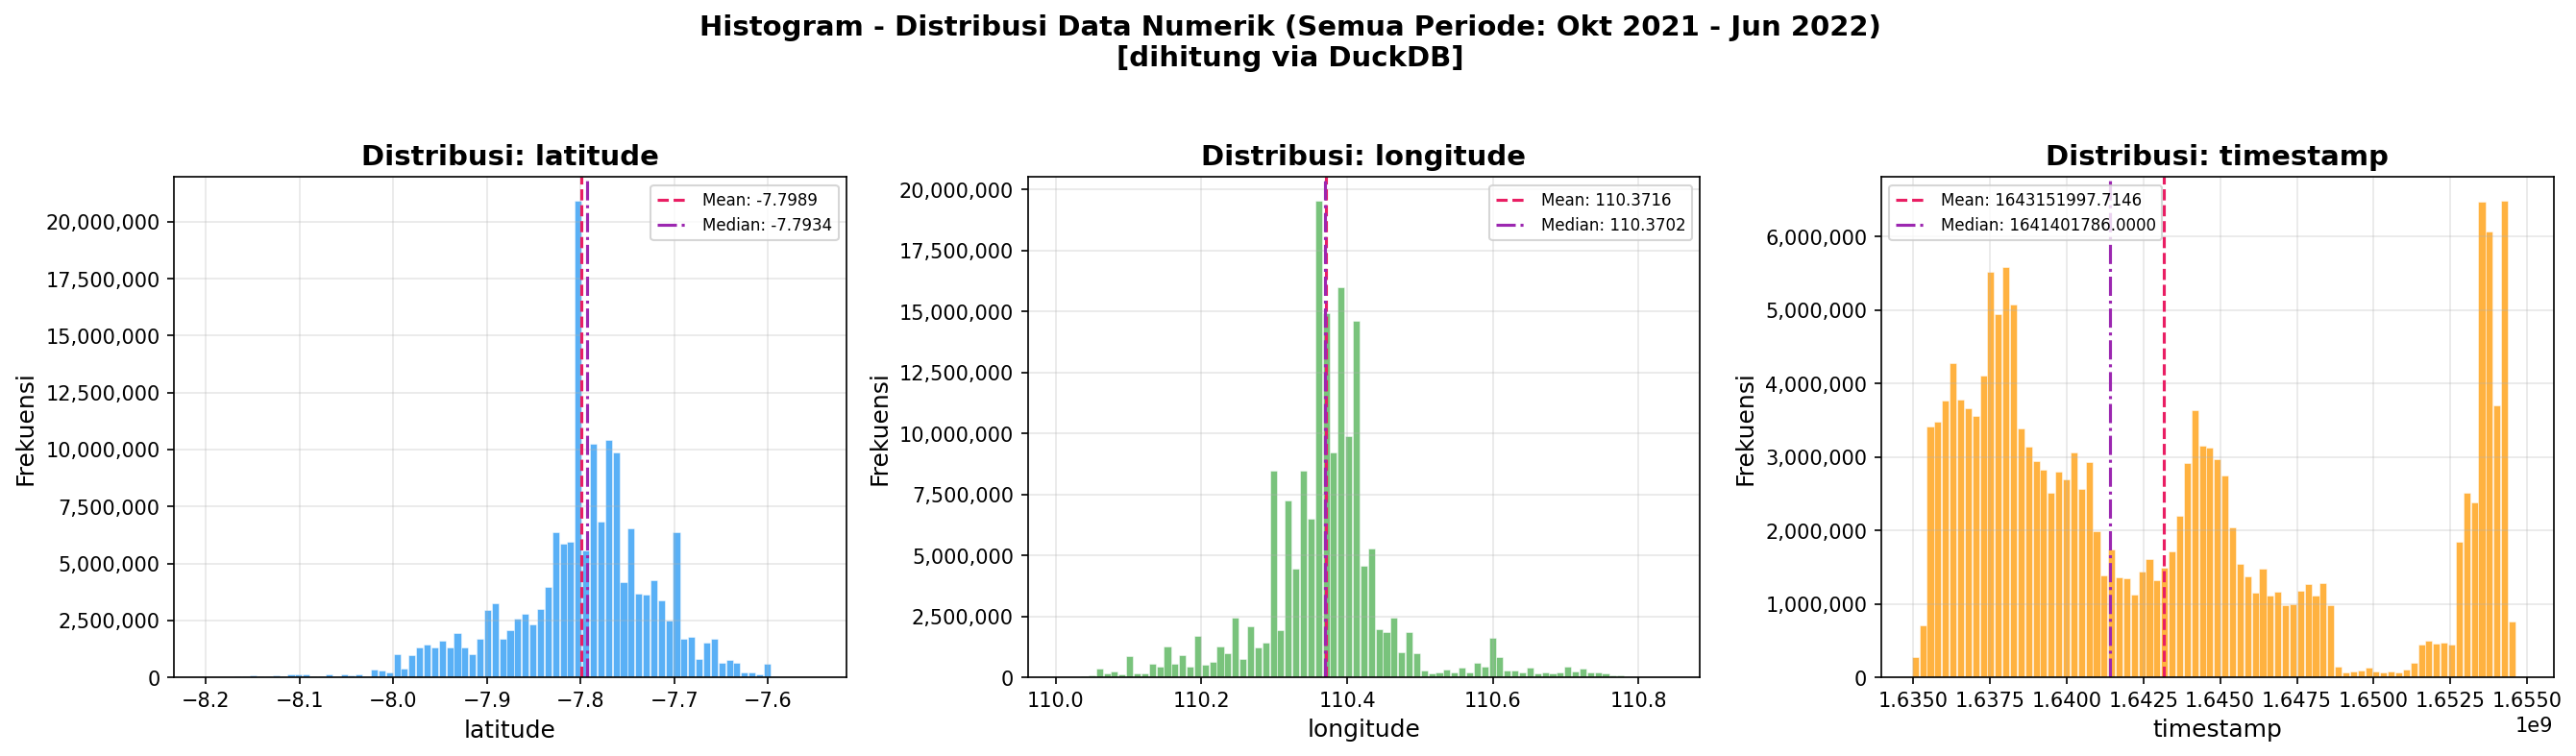

✅ Histogram tersimpan


In [14]:
numeric_columns = ["latitude", "longitude", "timestamp"]
colors = ["#2196F3", "#4CAF50", "#FF9800"]
mean_keys = ["lat_mean", "lon_mean", "ts_mean"]
median_keys = ["lat_median", "lon_median", "ts_median"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numeric_columns):
    ax = axes[idx]
    hist_data, bin_width = duckdb_histogram(con, col, n_bins=80)
    
    ax.bar(hist_data["bin_center"], hist_data["cnt"], width=bin_width * 0.9,
           color=colors[idx], alpha=0.75, edgecolor="white", linewidth=0.3)
    
    # Mean & median lines
    mean_val = float(stats_for_hist[mean_keys[idx]].iloc[0])
    median_val = float(stats_for_hist[median_keys[idx]].iloc[0])
    ax.axvline(mean_val, color="#E91E63", linestyle="--", linewidth=1.5, 
               label=f"Mean: {mean_val:.4f}")
    ax.axvline(median_val, color="#9C27B0", linestyle="-.", linewidth=1.5,
               label=f"Median: {median_val:.4f}")
    
    ax.set_title(f"Distribusi: {col}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("Histogram - Distribusi Data Numerik (Semua Periode: Okt 2021 - Jun 2022)\n[dihitung via DuckDB]", 
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/hist_distribusi_all_data_gps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Histogram tersimpan")

---
## 11 · Distribusi Data — Boxplot (percentile-based)

Boxplot dihitung dari percentile yang sudah ada di `desc_df` — tanpa load data mentah.

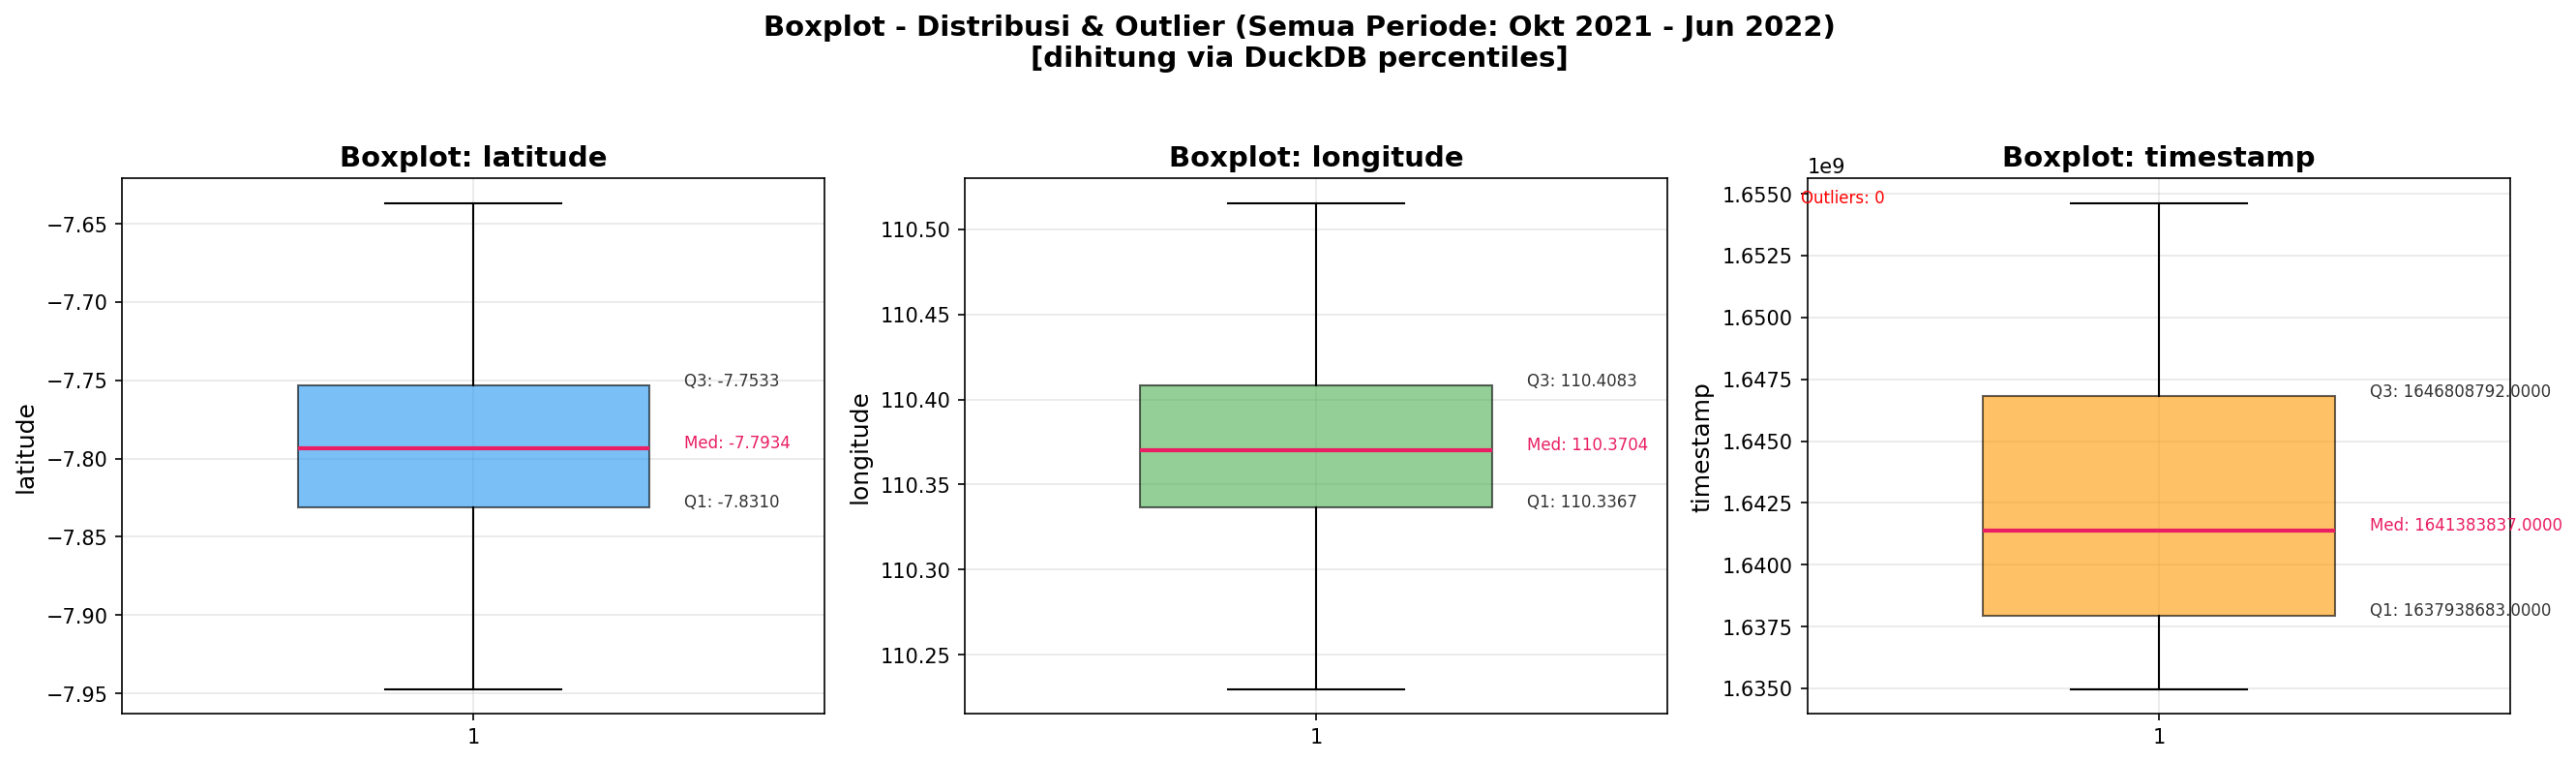

✅ Boxplot tersimpan


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(["latitude", "longitude", "timestamp"]):
    ax = axes[idx]
    
    row = desc_df.loc[col]
    q1, median, q3 = float(row["q1"]), float(row["median"]), float(row["q3"])
    vmin, vmax = float(row["min"]), float(row["max"])
    iqr = q3 - q1
    
    # Whiskers (capped at actual min/max)
    lower_whisker = max(vmin, q1 - 1.5 * iqr)
    upper_whisker = min(vmax, q3 + 1.5 * iqr)
    
    # Hitung jumlah outlier via DuckDB
    outlier_count = con.execute(f"""
        SELECT COUNT(*) AS n 
        FROM gps 
        WHERE {col} < {lower_whisker} OR {col} > {upper_whisker}
    """).fetchone()[0]
    
    # Draw boxplot manually
    box_color = colors[idx]
    bp = ax.bxp([{
        "med": median, "q1": q1, "q3": q3,
        "whislo": lower_whisker, "whishi": upper_whisker,
        "fliers": []
    }], patch_artist=True, widths=0.5)
    
    bp["boxes"][0].set_facecolor(box_color)
    bp["boxes"][0].set_alpha(0.6)
    bp["medians"][0].set_color("#E91E63")
    bp["medians"][0].set_linewidth(2)
    
    ax.set_title(f"Boxplot: {col}", fontweight="bold")
    ax.set_ylabel(col)
    
    # Annotasi
    ax.annotate(f"Q1: {q1:.4f}", xy=(1.3, q1), fontsize=8, color="#333")
    ax.annotate(f"Med: {median:.4f}", xy=(1.3, median), fontsize=8, color="#E91E63")
    ax.annotate(f"Q3: {q3:.4f}", xy=(1.3, q3), fontsize=8, color="#333")
    ax.annotate(f"Outliers: {outlier_count:,}", xy=(0.55, vmax), fontsize=8, 
                color="red", ha="center")

plt.suptitle("Boxplot - Distribusi & Outlier (Semua Periode: Okt 2021 - Jun 2022)\n[dihitung via DuckDB percentiles]",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/boxplot_distribusi_all_data_gps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Boxplot tersimpan")

---
## 12 · Korelasi antar Kolom Numerik

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

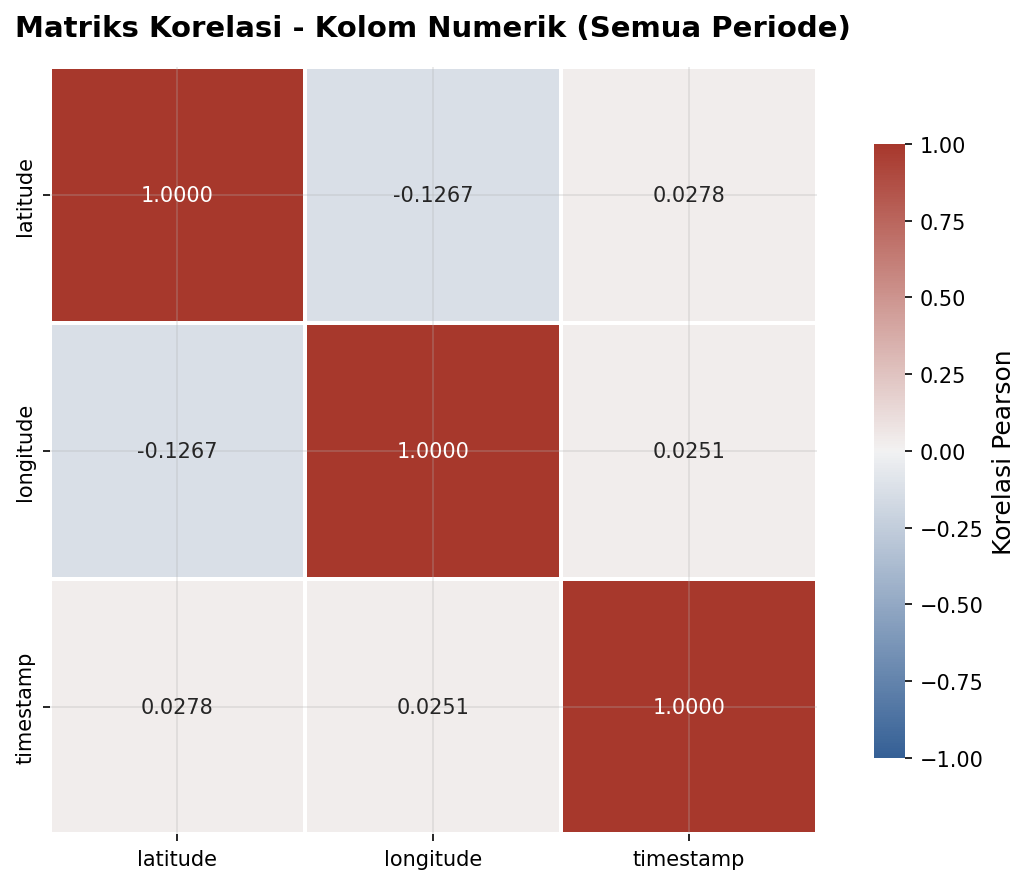

✅ Heatmap korelasi tersimpan

Matriks Korelasi Pearson:


,latitude,longitude,timestamp
latitude,1.000000,-0.126659,0.027798
longitude,-0.126659,1.000000,0.025090
timestamp,0.027798,0.025090,1.000000


In [16]:
corr_df = con.execute("""
    SELECT
        CORR(latitude, longitude)  AS lat_lon,
        CORR(latitude, timestamp)  AS lat_ts,
        CORR(longitude, timestamp) AS lon_ts
    FROM gps
""").df()

# Bangun matriks korelasi
labels = ["latitude", "longitude", "timestamp"]
corr_matrix = pd.DataFrame(np.ones((3, 3)), index=labels, columns=labels)
corr_matrix.loc["latitude", "longitude"] = corr_matrix.loc["longitude", "latitude"] = float(corr_df["lat_lon"].iloc[0])
corr_matrix.loc["latitude", "timestamp"] = corr_matrix.loc["timestamp", "latitude"] = float(corr_df["lat_ts"].iloc[0])
corr_matrix.loc["longitude", "timestamp"] = corr_matrix.loc["timestamp", "longitude"] = float(corr_df["lon_ts"].iloc[0])

fig, ax = plt.subplots(figsize=(8, 6))
cmap = sns.diverging_palette(250, 15, s=75, l=40, n=256, center="light")

sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap=cmap, center=0,
            square=True, linewidths=1, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "Korelasi Pearson"},
            ax=ax, vmin=-1, vmax=1)

ax.set_title("Matriks Korelasi - Kolom Numerik (Semua Periode)", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/korelasi_all_data_gps.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Heatmap korelasi tersimpan")
print("\nMatriks Korelasi Pearson:")
corr_matrix

---
## 13 · Analisis Temporal (Timestamp → Datetime)

Semua agregasi temporal dihitung di DuckDB.

In [17]:
# Rentang waktu
time_range = con.execute("""
    SELECT
        STRFTIME(TO_TIMESTAMP(MIN(timestamp)), '%Y-%m-%d %H:%M:%S') AS waktu_mulai,
        STRFTIME(TO_TIMESTAMP(MAX(timestamp)), '%Y-%m-%d %H:%M:%S') AS waktu_akhir,
        (MAX(timestamp) - MIN(timestamp)) / 86400.0 AS durasi_hari
    FROM gps
""").df()

print("Rentang waktu data:")
print(f"  Mulai : {time_range['waktu_mulai'].iloc[0]}")
print(f"  Akhir : {time_range['waktu_akhir'].iloc[0]}")
print(f"  Durasi: {time_range['durasi_hari'].iloc[0]:.2f} hari")

Rentang waktu data:
  Mulai : 2021-10-23 07:00:00
  Akhir : 2022-06-08 02:27:45
  Durasi: 227.81 hari


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

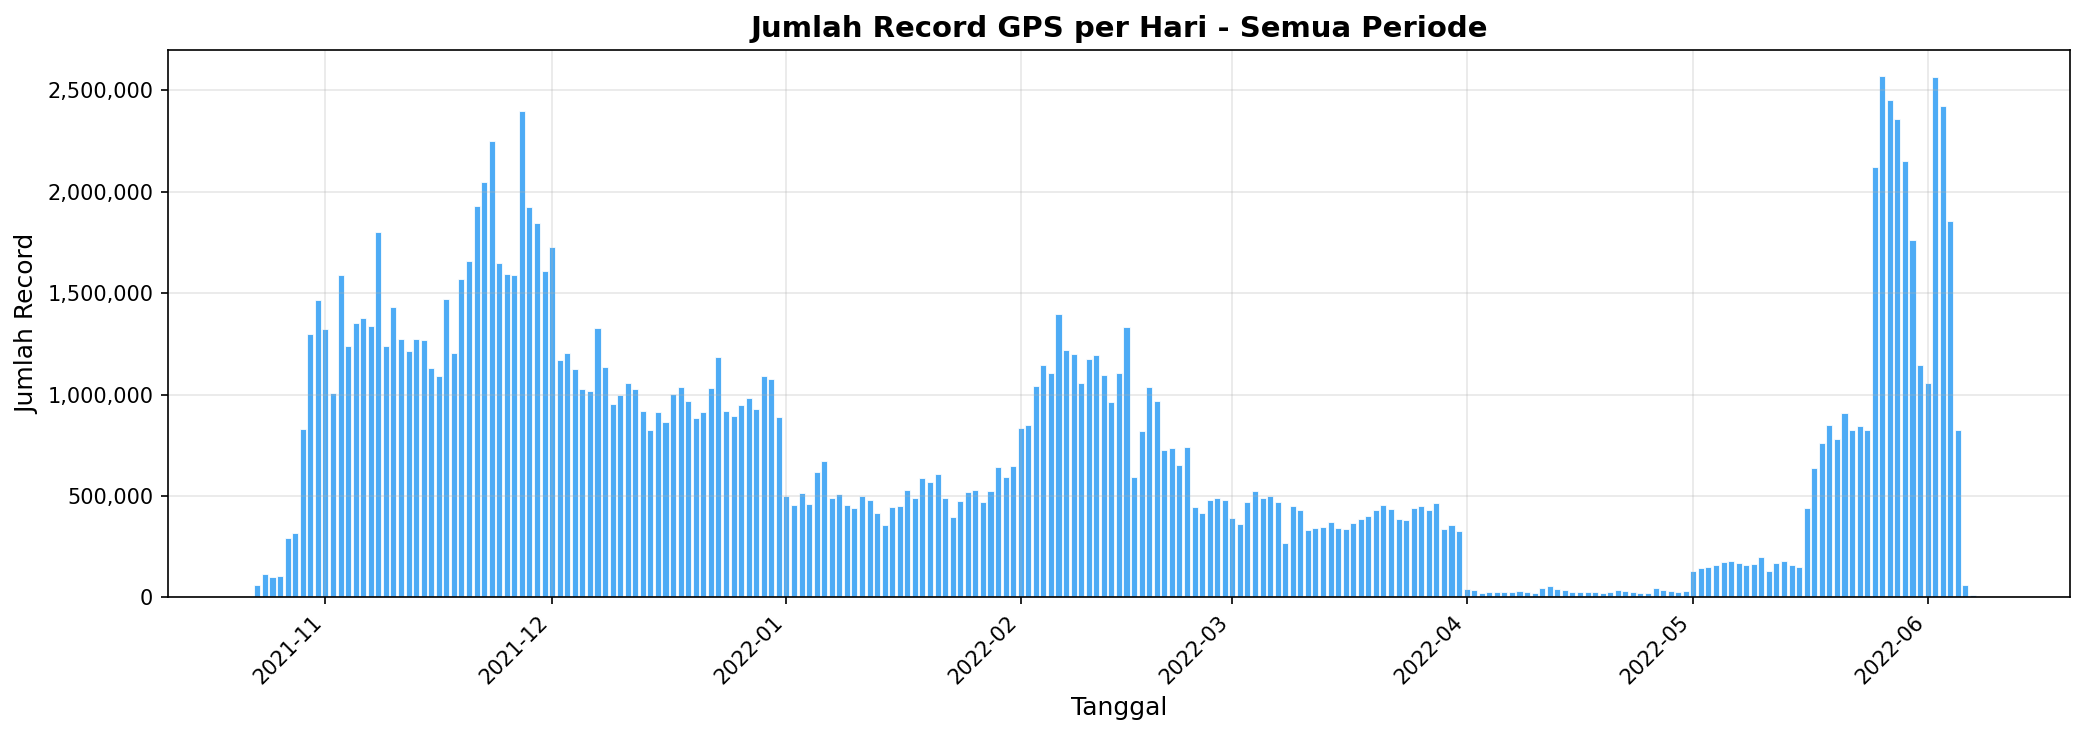

Total hari dengan data: 229
Rata-rata record/hari: 740,215
Min record/hari      : 2 (2022-06-08 00:00:00)
Max record/hari      : 2,572,985 (2022-05-26 00:00:00)


In [18]:
# Distribusi record per hari
daily_counts = con.execute("""
    SELECT 
        CAST(TO_TIMESTAMP(timestamp) AS DATE) AS tanggal,
        COUNT(*) AS count
    FROM gps
    GROUP BY tanggal
    ORDER BY tanggal
""").df()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(pd.to_datetime(daily_counts["tanggal"]), daily_counts["count"],
       color="#2196F3", alpha=0.8, edgecolor="white", linewidth=0.5)

ax.set_title("Jumlah Record GPS per Hari - Semua Periode", fontsize=14, fontweight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Jumlah Record")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/records_per_hari_all_data_gps.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total hari dengan data: {daily_counts.shape[0]}")
print(f"Rata-rata record/hari: {daily_counts['count'].mean():,.0f}")
print(f"Min record/hari      : {daily_counts['count'].min():,} ({daily_counts.loc[daily_counts['count'].idxmin(), 'tanggal']})")
print(f"Max record/hari      : {daily_counts['count'].max():,} ({daily_counts.loc[daily_counts['count'].idxmax(), 'tanggal']})")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

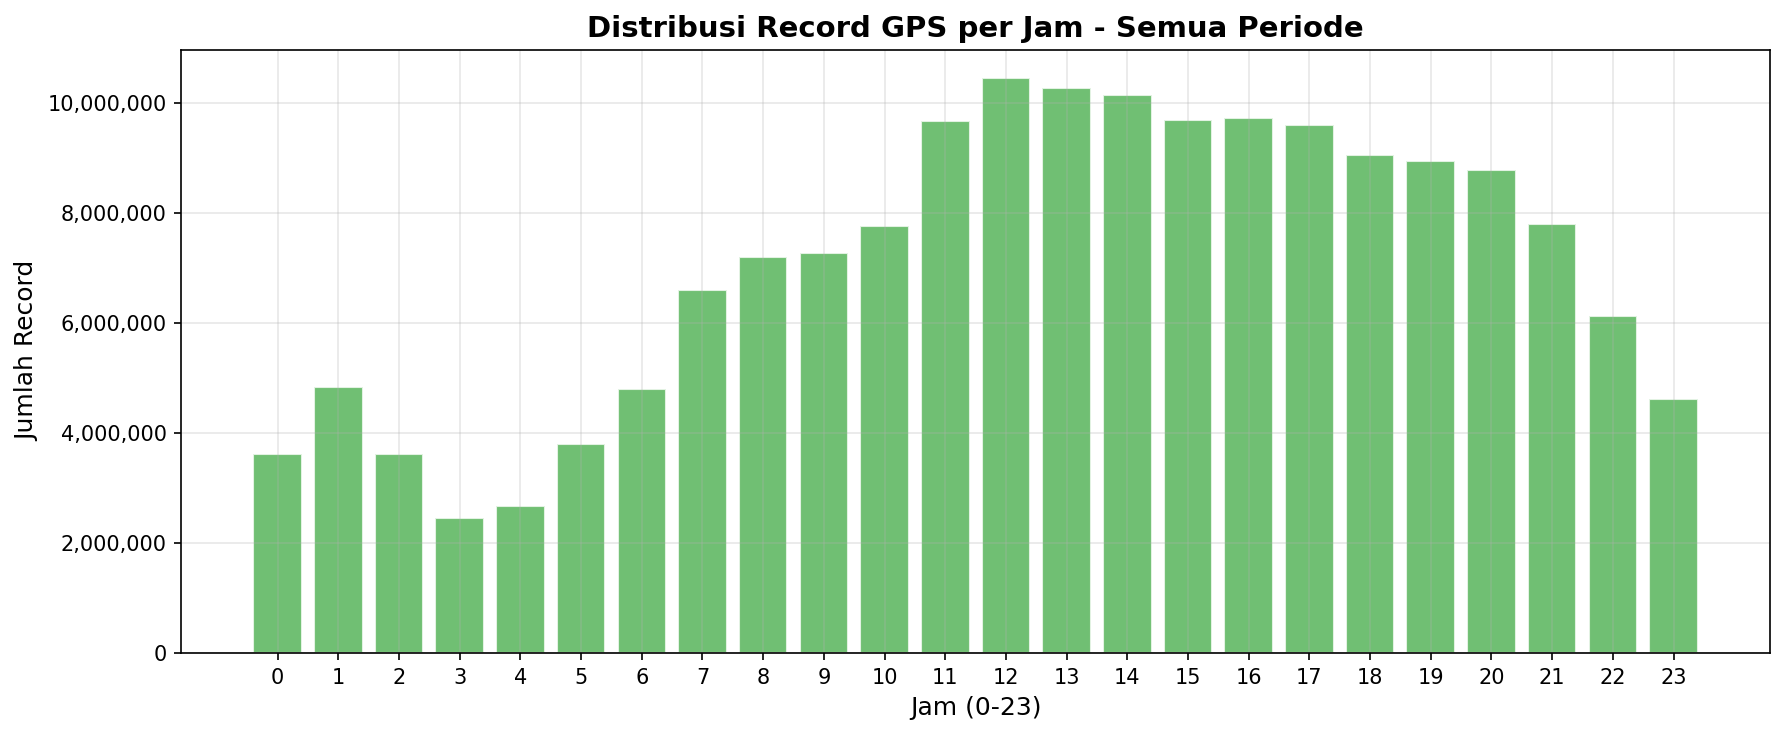

✅ Plot record per jam tersimpan


In [19]:
# Distribusi record per jam
hourly_counts = con.execute("""
    SELECT 
        EXTRACT(HOUR FROM TO_TIMESTAMP(timestamp)) AS jam,
        COUNT(*) AS count
    FROM gps
    GROUP BY jam
    ORDER BY jam
""").df()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_counts["jam"], hourly_counts["count"],
       color="#4CAF50", alpha=0.8, edgecolor="white", width=0.8)

ax.set_title("Distribusi Record GPS per Jam - Semua Periode", fontsize=14, fontweight="bold")
ax.set_xlabel("Jam (0-23)")
ax.set_ylabel("Jumlah Record")
ax.set_xticks(range(24))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/records_per_jam_all_data_gps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot record per jam tersimpan")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

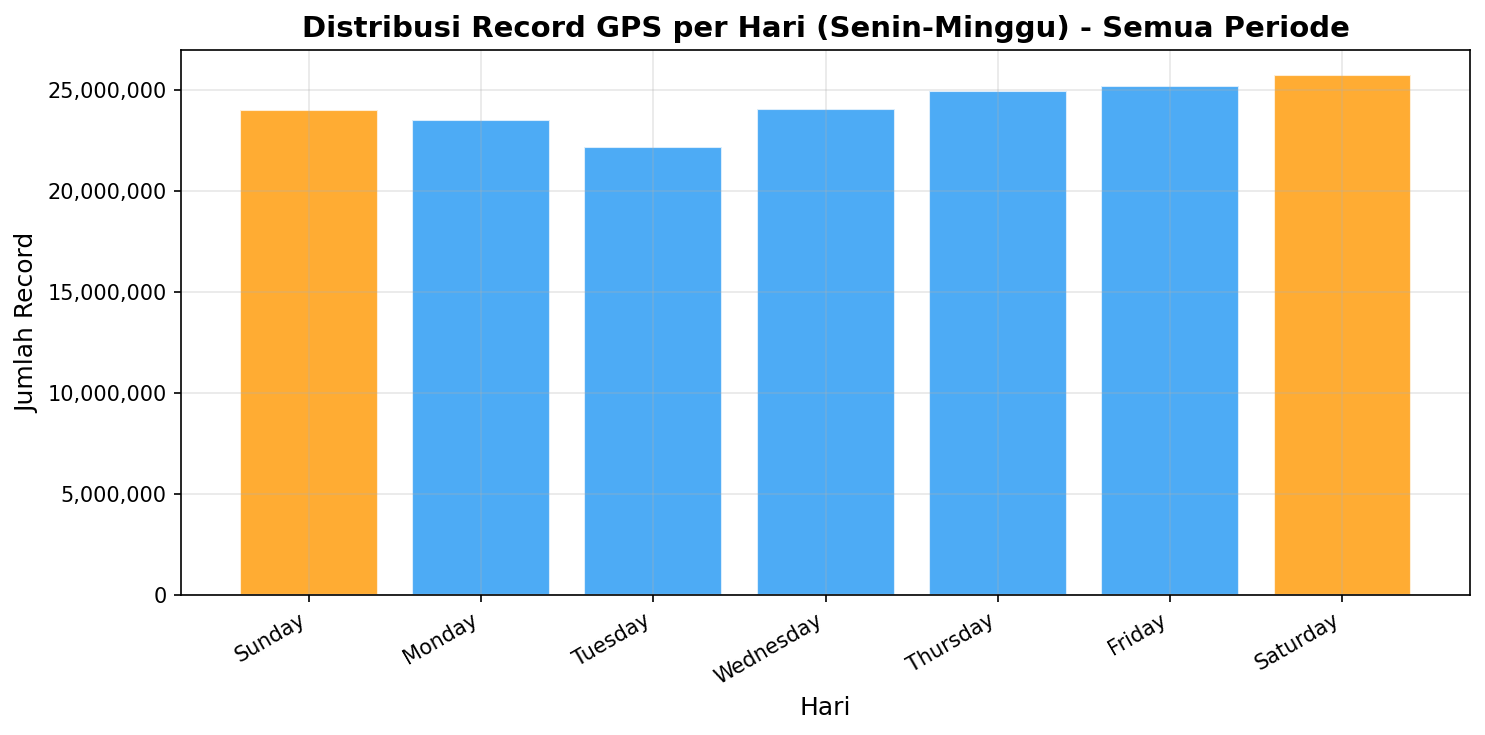

✅ Plot record per hari dalam seminggu tersimpan


In [20]:
# Distribusi per hari dalam seminggu
dow_counts = con.execute("""
    SELECT 
        DAYNAME(TO_TIMESTAMP(timestamp)) AS hari,
        DAYOFWEEK(TO_TIMESTAMP(timestamp)) AS dow_num,
        COUNT(*) AS count
    FROM gps
    GROUP BY hari, dow_num
    ORDER BY dow_num
""").df()

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ["#FF9800" if d in [0, 6] else "#2196F3" for d in dow_counts["dow_num"]]
ax.bar(dow_counts["hari"], dow_counts["count"], color=bar_colors, alpha=0.8, edgecolor="white")

ax.set_title("Distribusi Record GPS per Hari (Senin-Minggu) - Semua Periode",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Hari")
ax.set_ylabel("Jumlah Record")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/records_per_dow_all_data_gps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot record per hari dalam seminggu tersimpan")

---
## 14 · Distribusi Spasial (Scatter Plot Lat/Lon)

Sample data diambil via DuckDB `TABLESAMPLE` — tidak load seluruh dataset.

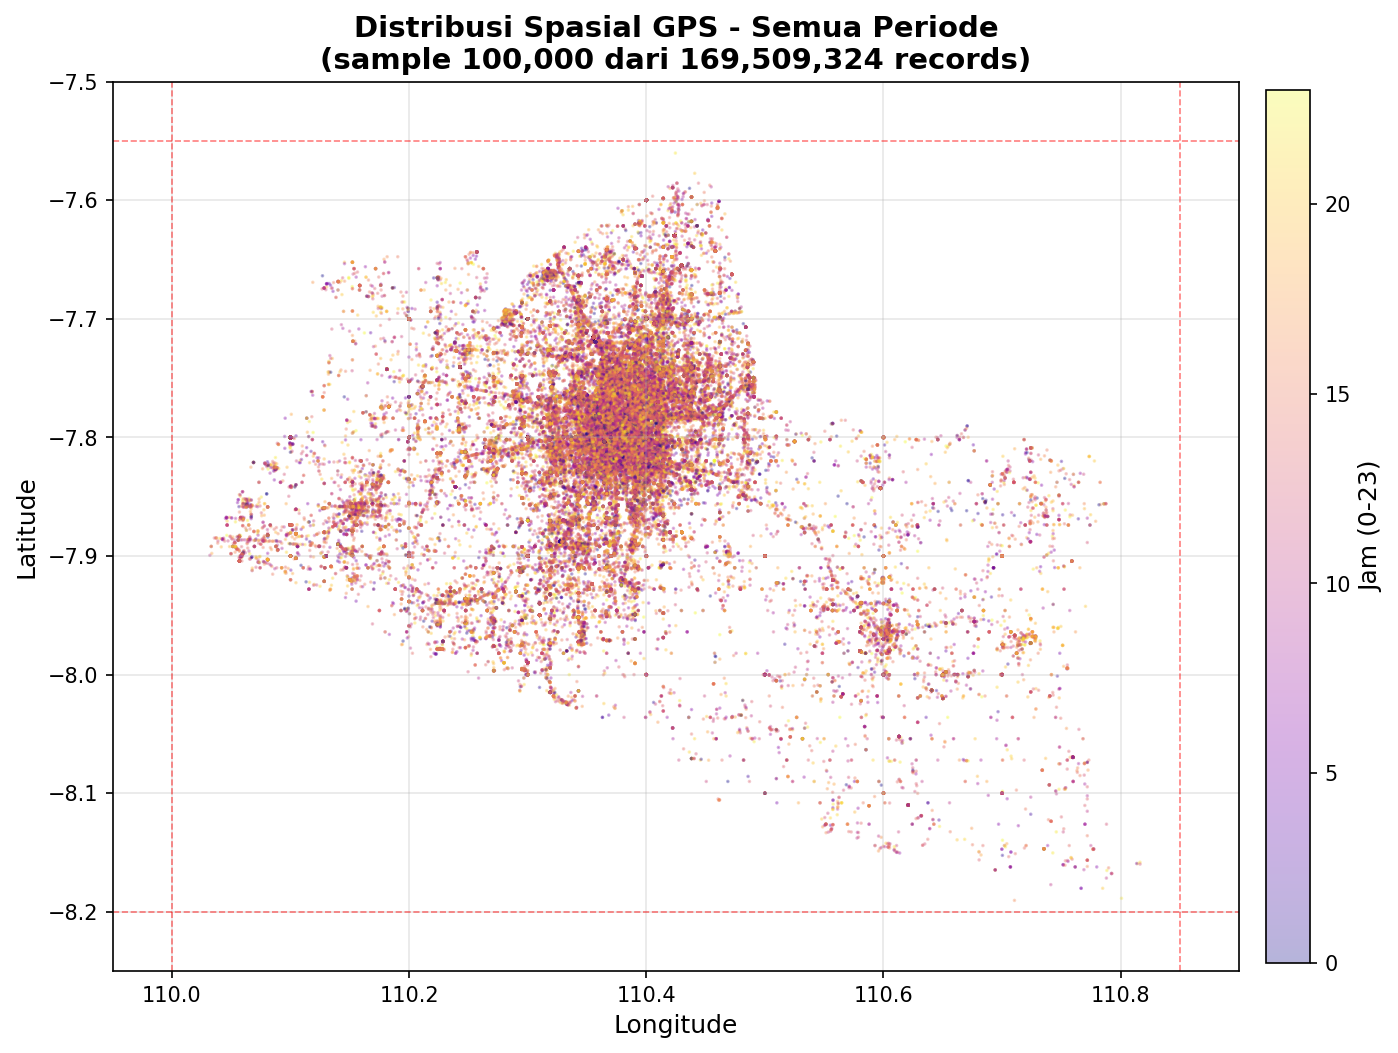

✅ Scatter plot spasial tersimpan


In [21]:
# Sample 100k baris via DuckDB
sample_size = 100_000

df_sample = con.execute(f"""
    SELECT latitude, longitude,
           EXTRACT(HOUR FROM TO_TIMESTAMP(timestamp)) AS hour
    FROM gps
    USING SAMPLE {sample_size} ROWS
""").df()

fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    df_sample["longitude"], df_sample["latitude"],
    c=df_sample["hour"], cmap="plasma",
    s=0.5, alpha=0.3,
 )

# Batas wilayah DIY
ax.axhline(LAT_MIN, color="red", linestyle="--", alpha=0.5, linewidth=0.8)
ax.axhline(LAT_MAX, color="red", linestyle="--", alpha=0.5, linewidth=0.8)
ax.axvline(LON_MIN, color="red", linestyle="--", alpha=0.5, linewidth=0.8)
ax.axvline(LON_MAX, color="red", linestyle="--", alpha=0.5, linewidth=0.8)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Jam (0-23)")

ax.set_title(f"Distribusi Spasial GPS - Semua Periode\n(sample {sample_size:,} dari {n_rows:,} records)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(LON_MIN - 0.05, LON_MAX + 0.05)
ax.set_ylim(LAT_MIN - 0.05, LAT_MAX + 0.05)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/distribusi_spasial_all_data_gps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Scatter plot spasial tersimpan")

del df_sample  # free memory

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

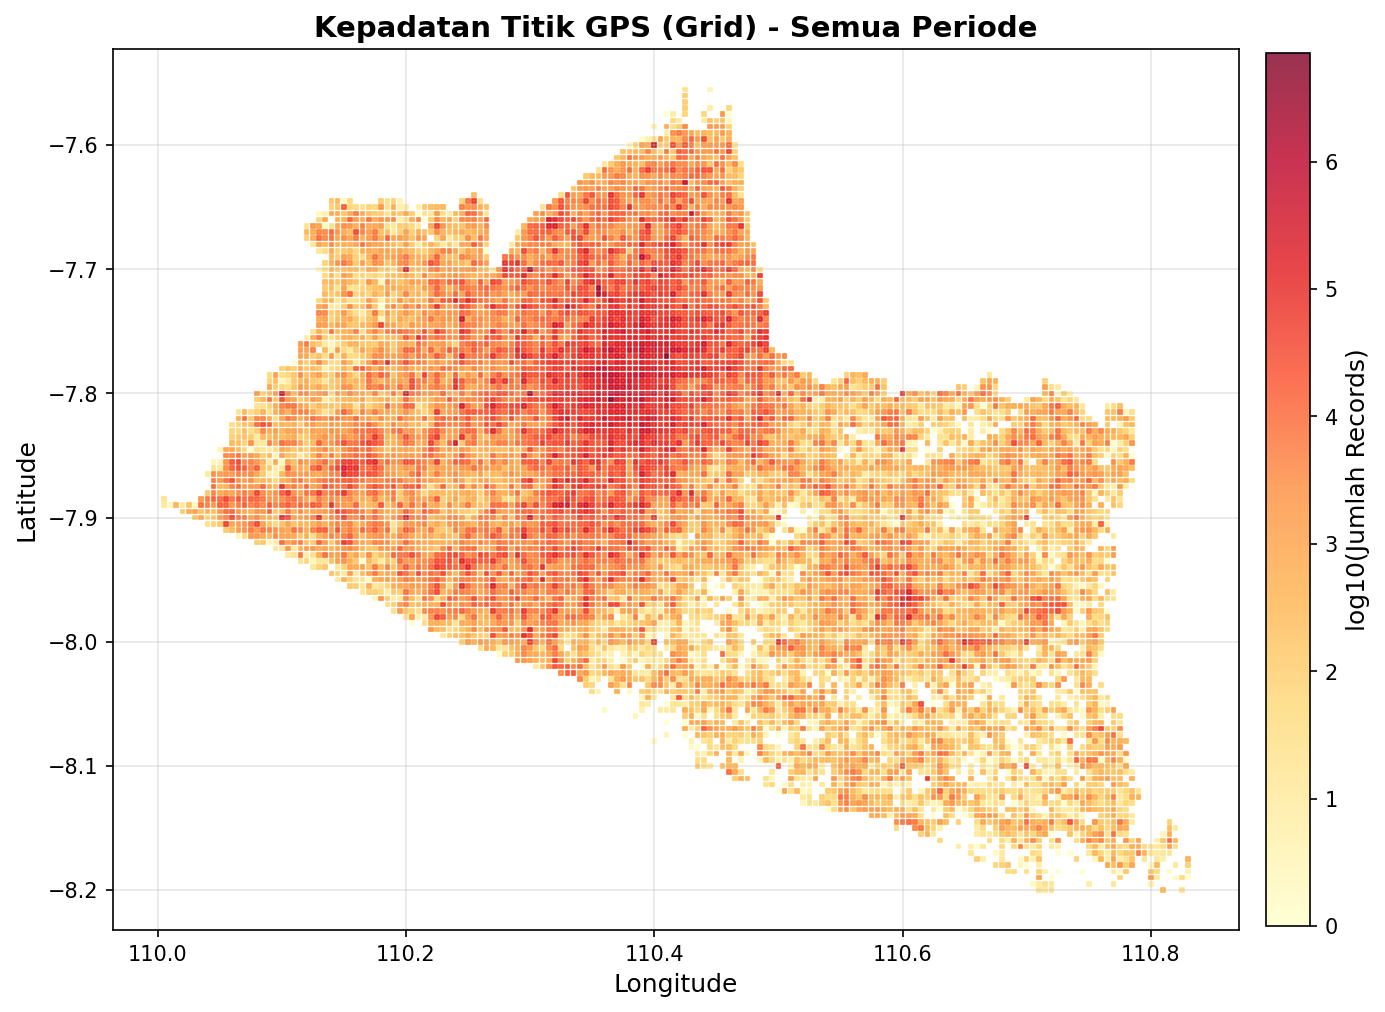

✅ Density grid plot tersimpan


In [22]:
# Heatmap 2D (hexbin) — via DuckDB grid aggregation
hexbin_data = con.execute(f"""
    SELECT 
        ROUND(longitude * 200) / 200 AS lon_grid,
        ROUND(latitude * 200) / 200  AS lat_grid,
        COUNT(*) AS cnt
    FROM gps
    WHERE latitude BETWEEN {LAT_MIN} AND {LAT_MAX}
      AND longitude BETWEEN {LON_MIN} AND {LON_MAX}
    GROUP BY lon_grid, lat_grid
""").df()

fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(
    hexbin_data["lon_grid"], hexbin_data["lat_grid"],
    c=np.log10(hexbin_data["cnt"]), cmap="YlOrRd",
    s=3, alpha=0.8, marker="s"
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("log10(Jumlah Records)")

ax.set_title("Kepadatan Titik GPS (Grid) - Semua Periode", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/hexbin_spasial_all_data_gps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Density grid plot tersimpan")

del hexbin_data

---
## 15 · Analisis Perangkat (MAID)

In [23]:
print("=" * 60)
print("ANALISIS PERANGKAT (MAID)")
print("=" * 60)

# Gunakan memory disk spilling DuckDB sepenuhnya dengan APPROX methods
maid_stats = con.execute("""
    WITH per_maid AS (
        SELECT maid, COUNT(*) AS n 
        FROM gps 
        GROUP BY maid
    )
    SELECT
        COUNT(*)                             AS jumlah_perangkat,
        AVG(n)                               AS rata_rata,
        APPROX_QUANTILE(n, 0.5)              AS median_records,
        MIN(n)                               AS min_records,
        MAX(n)                               AS max_records,
        STDDEV_SAMP(n)                       AS std_records
    FROM per_maid
""").df()

n_unique_maid = int(maid_stats["jumlah_perangkat"].iloc[0])

print(f"  Jumlah perangkat unik (MAID) : {n_unique_maid:,}")
print(f"  Rata-rata records/perangkat  : {maid_stats['rata_rata'].iloc[0]:.2f}")
print(f"  Median records/perangkat     : {maid_stats['median_records'].iloc[0]:.2f}")
print(f"  Min records/perangkat        : {int(maid_stats['min_records'].iloc[0]):,}")
print(f"  Max records/perangkat        : {int(maid_stats['max_records'].iloc[0]):,}")
print(f"  Std records/perangkat        : {maid_stats['std_records'].iloc[0]:.2f}")

ANALISIS PERANGKAT (MAID)
  Jumlah perangkat unik (MAID) : 4,281,537
  Rata-rata records/perangkat  : 39.59
  Median records/perangkat     : 3.00
  Min records/perangkat        : 1
  Max records/perangkat        : 313,129
  Std records/perangkat        : 487.01


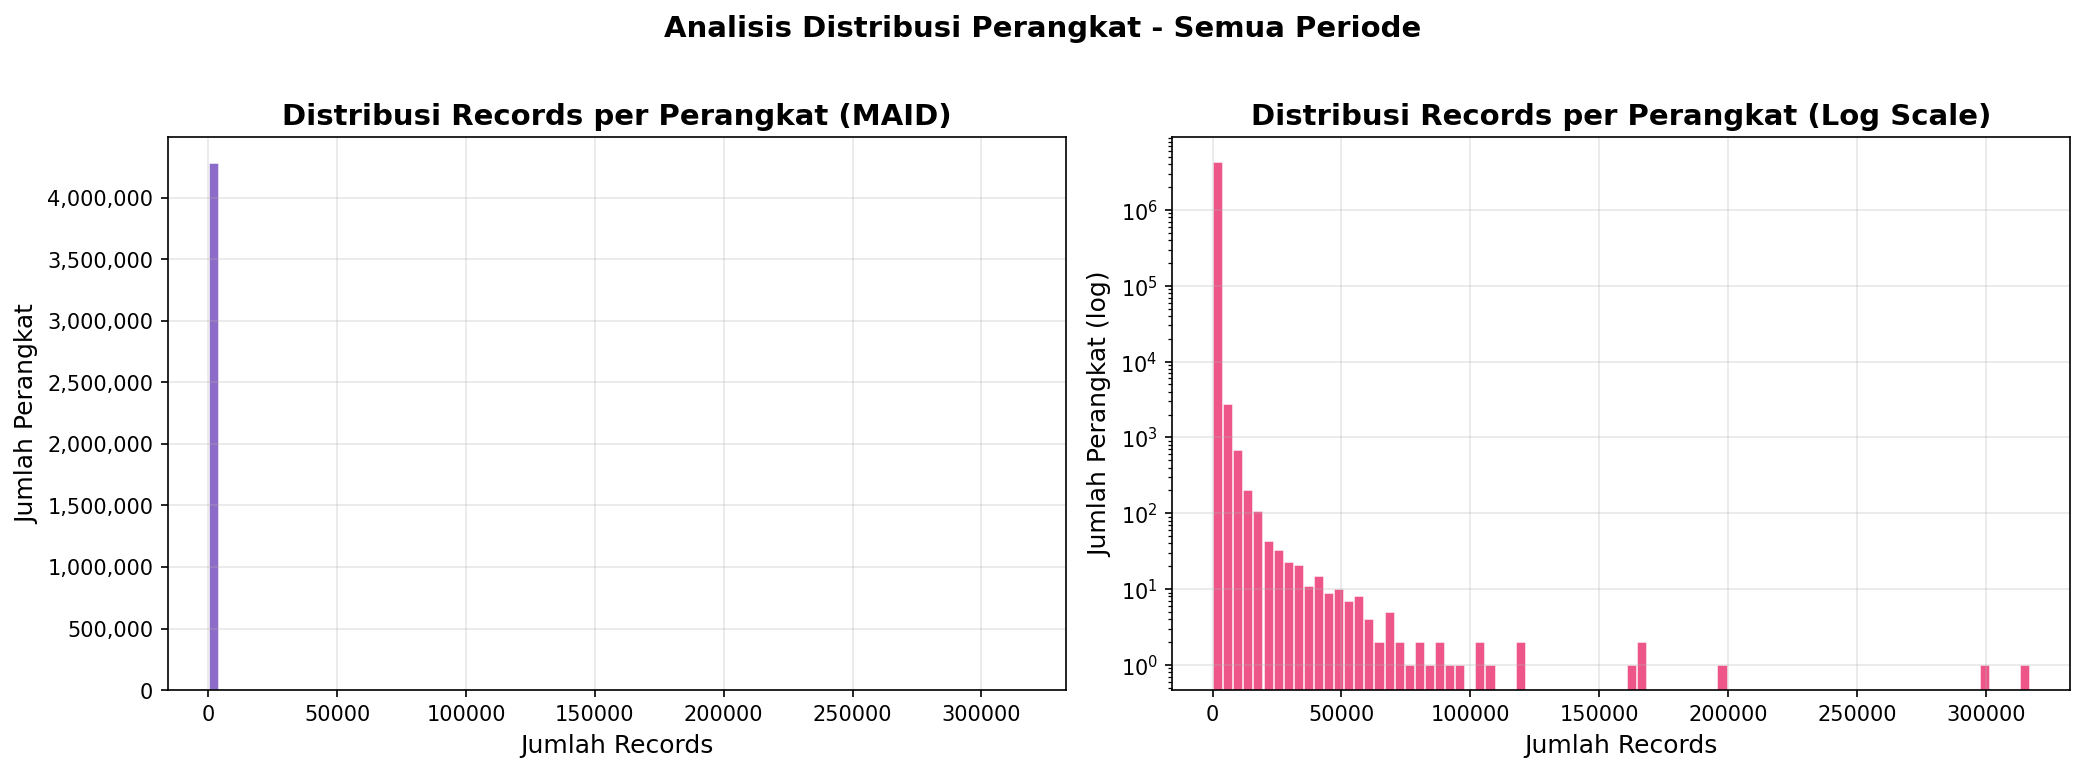

✅ Plot distribusi perangkat tersimpan


In [24]:
# 1. Simpan agregasi ke Tabel Sementara agar DuckDB tidak menghitung jutaan data 2x
con.execute("CREATE OR REPLACE TEMP TABLE per_maid_counts AS SELECT maid, COUNT(*) AS n FROM gps GROUP BY maid")

# 2. Ambil nilai min & max secara terpisah (menghindari memory bloat dari Cross-Join SQL)
stats_df = con.execute("SELECT MIN(n) AS vmin, MAX(n) AS vmax FROM per_maid_counts").df()
vmin = float(stats_df["vmin"].iloc[0])
vmax = float(stats_df["vmax"].iloc[0])

# 3. Cegah pembagian dengan nol & hitung lebar bin di Python
bin_width = max((vmax - vmin) / 80.0, 1.0)

# 4. Lakukan Binning langsung (cepat karena max puluhan juta baris, bukan ratusan juta)
maid_hist = con.execute(f"""
    SELECT
        FLOOR((n - {vmin}) / {bin_width}) AS bin_idx,
        COUNT(*) AS cnt
    FROM per_maid_counts
    GROUP BY bin_idx
    ORDER BY bin_idx
""").df()

# 5. Hapus tabel sementara untuk membebaskan memory / storage
con.execute("DROP TABLE per_maid_counts")

# Bersihkan hasil ke format plotting
maid_hist["bin_center"] = vmin + (maid_hist["bin_idx"] + 0.5) * bin_width

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Linear scale
ax = axes[0]
ax.bar(maid_hist["bin_center"], maid_hist["cnt"], width=bin_width * 0.9,
       color="#673AB7", alpha=0.75, edgecolor="white", linewidth=0.3)
ax.set_title("Distribusi Records per Perangkat (MAID)", fontweight="bold")
ax.set_xlabel("Jumlah Records")
ax.set_ylabel("Jumlah Perangkat")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# (b) Log scale
ax = axes[1]
ax.bar(maid_hist["bin_center"], maid_hist["cnt"], width=bin_width * 0.9,
       color="#E91E63", alpha=0.75, edgecolor="white", linewidth=0.3)
ax.set_title("Distribusi Records per Perangkat (Log Scale)", fontweight="bold")
ax.set_xlabel("Jumlah Records")
ax.set_ylabel("Jumlah Perangkat (log)")
ax.set_yscale("log")

plt.suptitle("Analisis Distribusi Perangkat - Semua Periode", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/distribusi_perangkat_all_data_gps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot distribusi perangkat tersimpan")

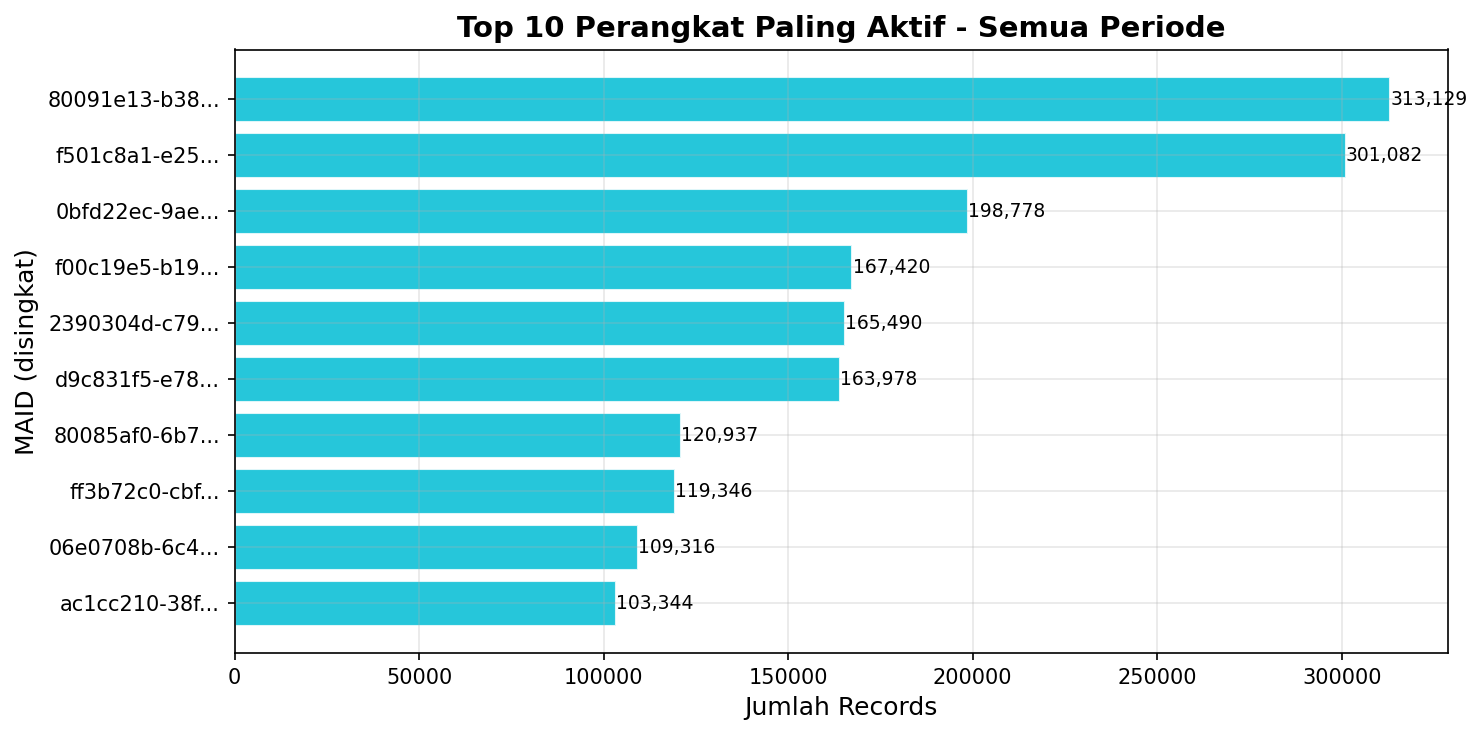

✅ Top 10 perangkat tersimpan


In [25]:
# Top 10 perangkat paling aktif
top10 = con.execute("""
    SELECT maid, COUNT(*) AS record_count
    FROM gps
    GROUP BY maid
    ORDER BY record_count DESC
    LIMIT 10
""").df()

top10["maid_short"] = top10["maid"].str[:12] + "..."

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10["maid_short"][::-1], top10["record_count"][::-1],
               color="#00BCD4", alpha=0.85, edgecolor="white")

for bar, count in zip(bars, top10["record_count"][::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f"{count:,}", va="center", fontsize=9)

ax.set_title("Top 10 Perangkat Paling Aktif - Semua Periode", fontweight="bold")
ax.set_xlabel("Jumlah Records")
ax.set_ylabel("MAID (disingkat)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/top10_perangkat_all_data_gps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Top 10 perangkat tersimpan")

---
## 16 · Ringkasan Akhir

In [26]:
# Ambil info tambahan untuk ringkasan
ts_range = con.execute("""
    SELECT 
        STRFTIME(TO_TIMESTAMP(MIN(timestamp)), '%Y-%m-%d') AS min_date,
        STRFTIME(TO_TIMESTAMP(MAX(timestamp)), '%Y-%m-%d') AS max_date,
        MIN(latitude)  AS lat_min,  MAX(latitude)  AS lat_max,
        MIN(longitude) AS lon_min,  MAX(longitude) AS lon_max,
        MIN(timestamp) AS ts_min,   MAX(timestamp) AS ts_max
    FROM gps
""").df()

print("=" * 70)
print("                    📋 RINGKASAN DATA DESCRIPTION")
print("                    GPS Semua Periode (Okt 2021 - Jun 2022) — Wilayah DIY")
print("=" * 70)
print()
print(f"  📁 File Sumber            : {PARQUET_PATH}")
print(f"  ⚡ Processing Engine      : DuckDB (disk spilling, 4GB limit)")
print(f"  📏 Jumlah Baris           : {n_rows:>12,}")
print(f"  📏 Jumlah Kolom           : {n_cols:>12}")
print(f"  📏 Distinct Rows          : {n_distinct_rows:>12,}")
print(f"  📏 Duplicate Rows         : {n_duplicate_rows:>12,}")
print(f"  📏 Total Sel              : {n_rows * n_cols:>12,}")
print(f"  ❌ Total Null             : {total_nulls:>12,}")
print(f"  📍 Distinct MAID          : {n_unique_maid:>12,}")
print(f"  📅 Rentang Tanggal        : {ts_range['min_date'].iloc[0]} s/d {ts_range['max_date'].iloc[0]}")
print(f"  🌐 Latitude Range         : [{ts_range['lat_min'].iloc[0]:.6f}, {ts_range['lat_max'].iloc[0]:.6f}]")
print(f"  🌐 Longitude Range        : [{ts_range['lon_min'].iloc[0]:.6f}, {ts_range['lon_max'].iloc[0]:.6f}]")
print(f"  ⏱️  Timestamp Range        : [{int(ts_range['ts_min'].iloc[0]):,}, {int(ts_range['ts_max'].iloc[0]):,}]")
print(f"  📊 Rata-rata record/MAID  : {maid_stats['rata_rata'].iloc[0]:.2f}")
print(f"  📊 Rata-rata record/hari  : {daily_counts['count'].mean():,.0f}")
print()
print("=" * 70)
print("  ✅ Data Description selesai!")
print("=" * 70)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                    📋 RINGKASAN DATA DESCRIPTION
                    GPS Semua Periode (Okt 2021 - Jun 2022) — Wilayah DIY

  📁 File Sumber            : ./DataGPS_parquet/all_gps_data_no_dup.parquet
  ⚡ Processing Engine      : DuckDB (disk spilling, 4GB limit)
  📏 Jumlah Baris           :  169,509,324
  📏 Jumlah Kolom           :            4
  📏 Distinct Rows          :  169,509,324
  📏 Duplicate Rows         :            0
  📏 Total Sel              :  678,037,296
  ❌ Total Null             :            0
  📍 Distinct MAID          :    4,281,537
  📅 Rentang Tanggal        : 2021-10-23 s/d 2022-06-08
  🌐 Latitude Range         : [-8.201930, -7.556430]
  🌐 Longitude Range        : [110.003189, 110.832291]
  ⏱️  Timestamp Range        : [1,634,947,200, 1,654,630,065]
  📊 Rata-rata record/MAID  : 39.59
  📊 Rata-rata record/hari  : 740,215

  ✅ Data Description selesai!


In [27]:
# Tutup koneksi DuckDB
con.close()
print("✅ Koneksi DuckDB ditutup")

✅ Koneksi DuckDB ditutup
